Tarea 1: Tomar la red neuronal, pasarle espectros reducidos de WDA y WDB (se eligen estos arbitrariamente, hay que justificar para el escrito y presentación) y graficar con PCA y t-SNE

In [2]:
#definir las rutas hacia los datos crudos (espectros `.dat`), el archivo de etiquetas originales (`label_data`) y el modelo pre-entrenado (.h5)

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

model_path = r'C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\models\model_4C_3FC.h5'
data_path = r'C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\sdss_dat_files'
csv_path = r'C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\scripts\only_wd.csv' 

In [22]:
#reconstrucción del modelo :
#la red neuronal se usa como un extractor de características

#se carga el modelo `.h5`, Keras a veces pierde la inicialización de los tensores. Lo solucionamos pasando un tensor "falso" (`dummy_input`) con la dimensión exacta que requiere la primera capa convolucional (3750 puntos).
#reconstruir el flujo del modelo capa por capa. Esto nos permite interceptar la salida (el espacio latente) en cualquier capa intermedia, como `flatten` o las convoluciones, para estudiar cómo la red abstrae los rasgos físicos de los espectros antes de forzar una clasificación.

In [23]:
from tensorflow import keras
from tensorflow.keras import layers

# cargar el modelo .h5
full_model = load_model(model_path)

dummy_input = np.zeros((1, 3750, 1))
_ = full_model.predict(dummy_input, verbose=0)

layer_name = 'flatten'
input_layer = layers.Input(shape=(3750, 1))
x = input_layer

for layer in full_model.layers:
    x = layer(x)
    if layer.name == layer_name:
        break

# crear el modelo extractor con esta nueva conexión
latent_extractor = Model(inputs=input_layer, outputs=x)

latent_extractor.summary()

C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)          │ (None, 3750, 1)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 1874, 128)           │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 937, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 467, 64)             │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 233, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 115, 32)             │           8,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 57, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 27, 16)              │           2,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 13, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 208)                 │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,760 (170.94 KB)

 Trainable params: 43,760 (170.94 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#función de preprocesamiento de espectros 
#Los espectros crudos de SDSS presentan variaciones en longitud y ruido. Esta función estandariza los datos para que la red neuronal pueda procesarlos matemáticamente.

#el modelo espera exactamente 3750 características. se recortamos o rellena con ceros (padding) para garantizar esta dimensión.

In [25]:
def process_spectrum(file_path):
    try:
        sed = np.loadtxt(file_path, unpack=True)
        flux = sed[1, 48:-400]
        
        # ajuste a 3750 puntos
        if len(flux) > 3750:
            diff = len(flux) - 3750
            start = diff // 2
            flux = flux[start : start + 3750]
        elif len(flux) < 3750:
            flux = np.pad(flux, (0, 3750 - len(flux)), 'constant')

        # normalizacion
        # usar el índice 2100, pero si es muy bajo o cero, usar la media.
        norm_val = flux[2100]
        if norm_val < 0.01: # Si es casi cero o negativo (ruido)
            norm_val = np.mean(flux)
        
        # si la media es 0 (archivo corrupto), devolver None
        if norm_val == 0:
            return None
            
        final_flux = flux / norm_val
        
        if not np.all(np.isfinite(final_flux)):
            return None
            
        return final_flux
    except Exception:
        return None

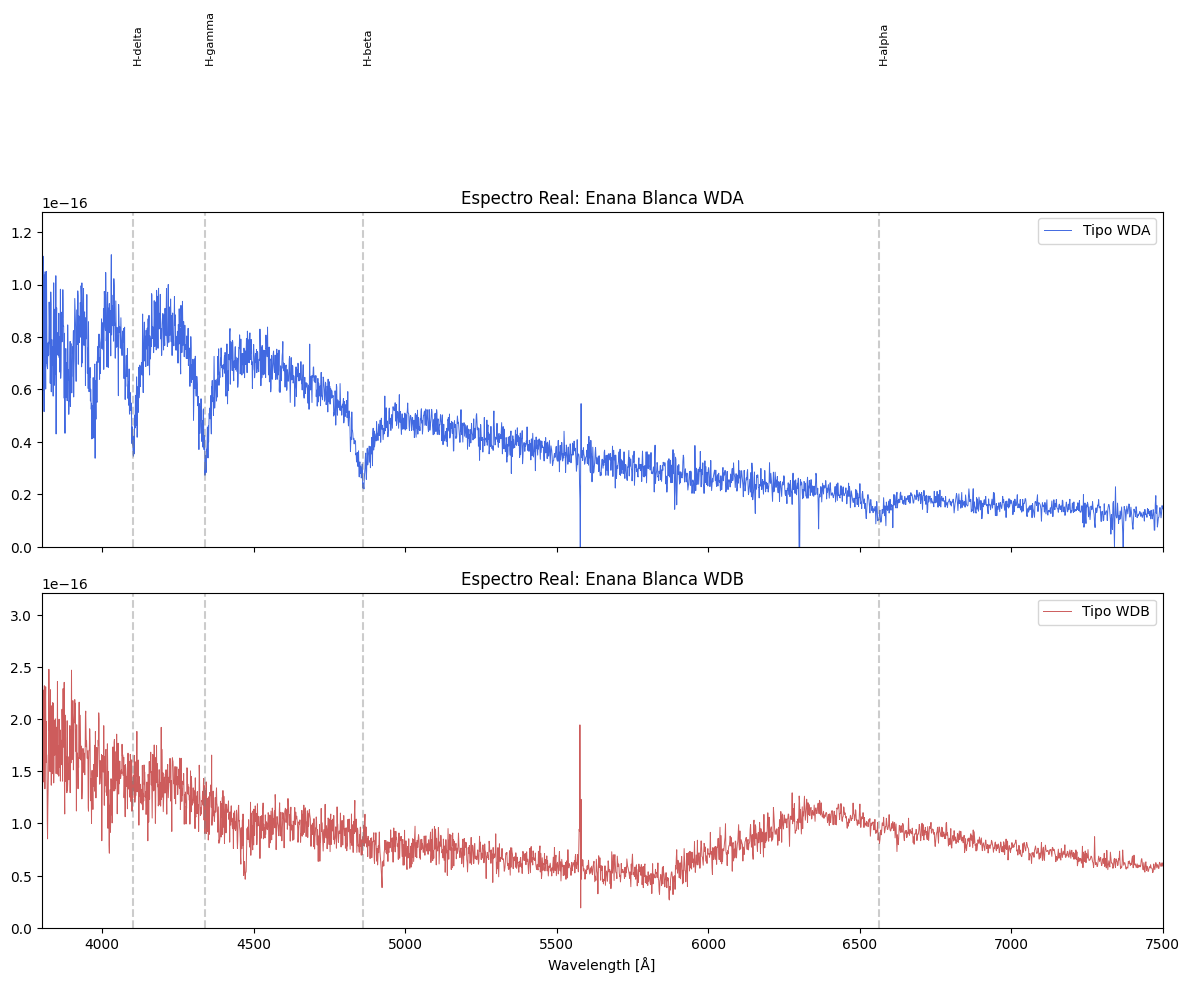

In [26]:
# Diccionario de líneas de Hidrógeno (Balmer) en Angstroms
balmer_lines = {'H-alpha': 6563, 'H-beta': 4861, 'H-gamma': 4340, 'H-delta': 4102}

ejemplo_wda = spectrum_df[spectrum_df['classID'] == 'WDA'].iloc[0]
ejemplo_wdb = spectrum_df[spectrum_df['classID'] == 'WDB'].iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for i, (ej, color) in enumerate(zip([ejemplo_wda, ejemplo_wdb], ['royalblue', 'indianred'])):
    f_path = os.path.join(data_path, ej['filename'])
    sed = np.loadtxt(f_path, unpack=True)
    
    # Graficar espectro
    axes[i].plot(sed[0,:], sed[1,:], linewidth=0.7, color=color, label=f"Tipo {ej['classID']}")
    
    # Dibujar líneas de referencia solo para que el profe las vea
    for name, wave in balmer_lines.items():
        axes[i].axvline(x=wave, color='gray', linestyle='--', alpha=0.4)
        if i == 0: # Solo poner texto en el primer gráfico para no saturar
            axes[i].text(wave, axes[i].get_ylim()[1]*0.8, name, rotation=90, fontsize=8)

    axes[i].set_title(f"Espectro Real: Enana Blanca {ej['classID']}")
    axes[i].set_xlim([3800, 7500]) # Zoom en la zona donde están las líneas más importantes
    axes[i].set_ylim([0, np.percentile(sed[1,:], 99) * 1.1])
    axes[i].legend()

plt.xlabel('Wavelength [Å]')
plt.tight_layout()
plt.show()

In [27]:
#cruce de Datos (Data Merging) y muestreo equilibrado

#se usa la convención de SDSS (`MJD_TargetID.dat`) para cruzar los archivos en el disco duro con el dataframe `raw_labels_df`, el cual contiene las etiquetas finas (WDA y WDB).

In [31]:
import os
import pandas as pd
import numpy as np

# cargar las etiquetas originales (donde están las clases WDA, WDB)
labels_path = r'C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\label_data'
fields = ['File Name', 'MJD', 'Target ID', 'DB ID' ,'Classification', 'Data Quality']
raw_labels_df = pd.DataFrame()

for filename in os.listdir(labels_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(labels_path, filename)
        df = pd.read_csv(file_path, usecols=fields)
        raw_labels_df = pd.concat([raw_labels_df, df], ignore_index=True)

# limpiar etiquetas no deseadas
clases_interes = ['WDA', 'WDB']
star_df = raw_labels_df[raw_labels_df['Classification'].isin(clases_interes)].copy()

file_dict = dict()
folder_list = os.listdir(data_path) # data_path definido en la Celda 1

for folder in folder_list:
    folder_full_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_full_path):
        file_list = os.listdir(folder_full_path)
        for filename in file_list:
            if filename.endswith('.dat'):
                # Esta es la lógica del notebook original para indexar
                # Extrae MJD y Target ID del nombre del archivo
                key = filename.split('-')[-2] + '_' + filename.split('_')[-1]
                file_dict[key] = os.path.join(folder, filename)

# crear el DataFrame final cruzando ambos
spectrum_list = []
for index, row in star_df.iterrows():
    filekey = str(row['MJD']) + '_' + str(row['Target ID']) + '.dat'
    
    if filekey in file_dict:
        spectrum_list.append({
            'filename': file_dict[filekey], 
            'classID': row['Classification']
        })

spectrum_df = pd.DataFrame(spectrum_list)
print(f"encontrados {len(spectrum_df)} espectros con etiquetas WDA/WDB.")


# Definimos un número seguro para la RAM y que existe en tus datos
# Usaremos 300 de cada una (Total 600 espectros)
n_muestras = 300 

df_wda = spectrum_df[spectrum_df['classID'] == 'WDA']
df_wdb = spectrum_df[spectrum_df['classID'] == 'WDB']

# Creamos el set equilibrado real
df_reduced = pd.concat([
    df_wda.sample(n=n_muestras, random_state=42),
    df_wdb.sample(n=n_muestras, random_state=42)
])

print(f"{len(df_reduced)} espectros totales.")
print(f"   - WDA: {n_muestras}")
print(f"   - WDB: {n_muestras}")

# cargar los nuevos sets a la memoria
X_list = []
y_labels = []

for _, row in df_reduced.iterrows():
    f_path = os.path.join(data_path, row['filename'])
    spec = process_spectrum(f_path) 
    if spec is not None:
        X_list.append(spec)
        y_labels.append(row['classID'])

X_final = np.array(X_list)
X_input = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))
print(f"matriz reducida lista para PCA/t-SNE: {X_input.shape}")

encontrados 14907 espectros con etiquetas WDA/WDB.
600 espectros totales.
   - WDA: 300
   - WDB: 300
matriz reducida lista para PCA/t-SNE: (599, 3750, 1)


In [32]:
#se evalúa qué tan bien la red neuronal ha aprendido a separar físicamente las enanas blancas con hidrógeno (WDA) de las que tienen helio (WDB), capa por capa.

#se recorrem desde las primeras capas convolucionales (que detectan características de bajo nivel como picos locales) hasta las capas densas (que combinan estas características).

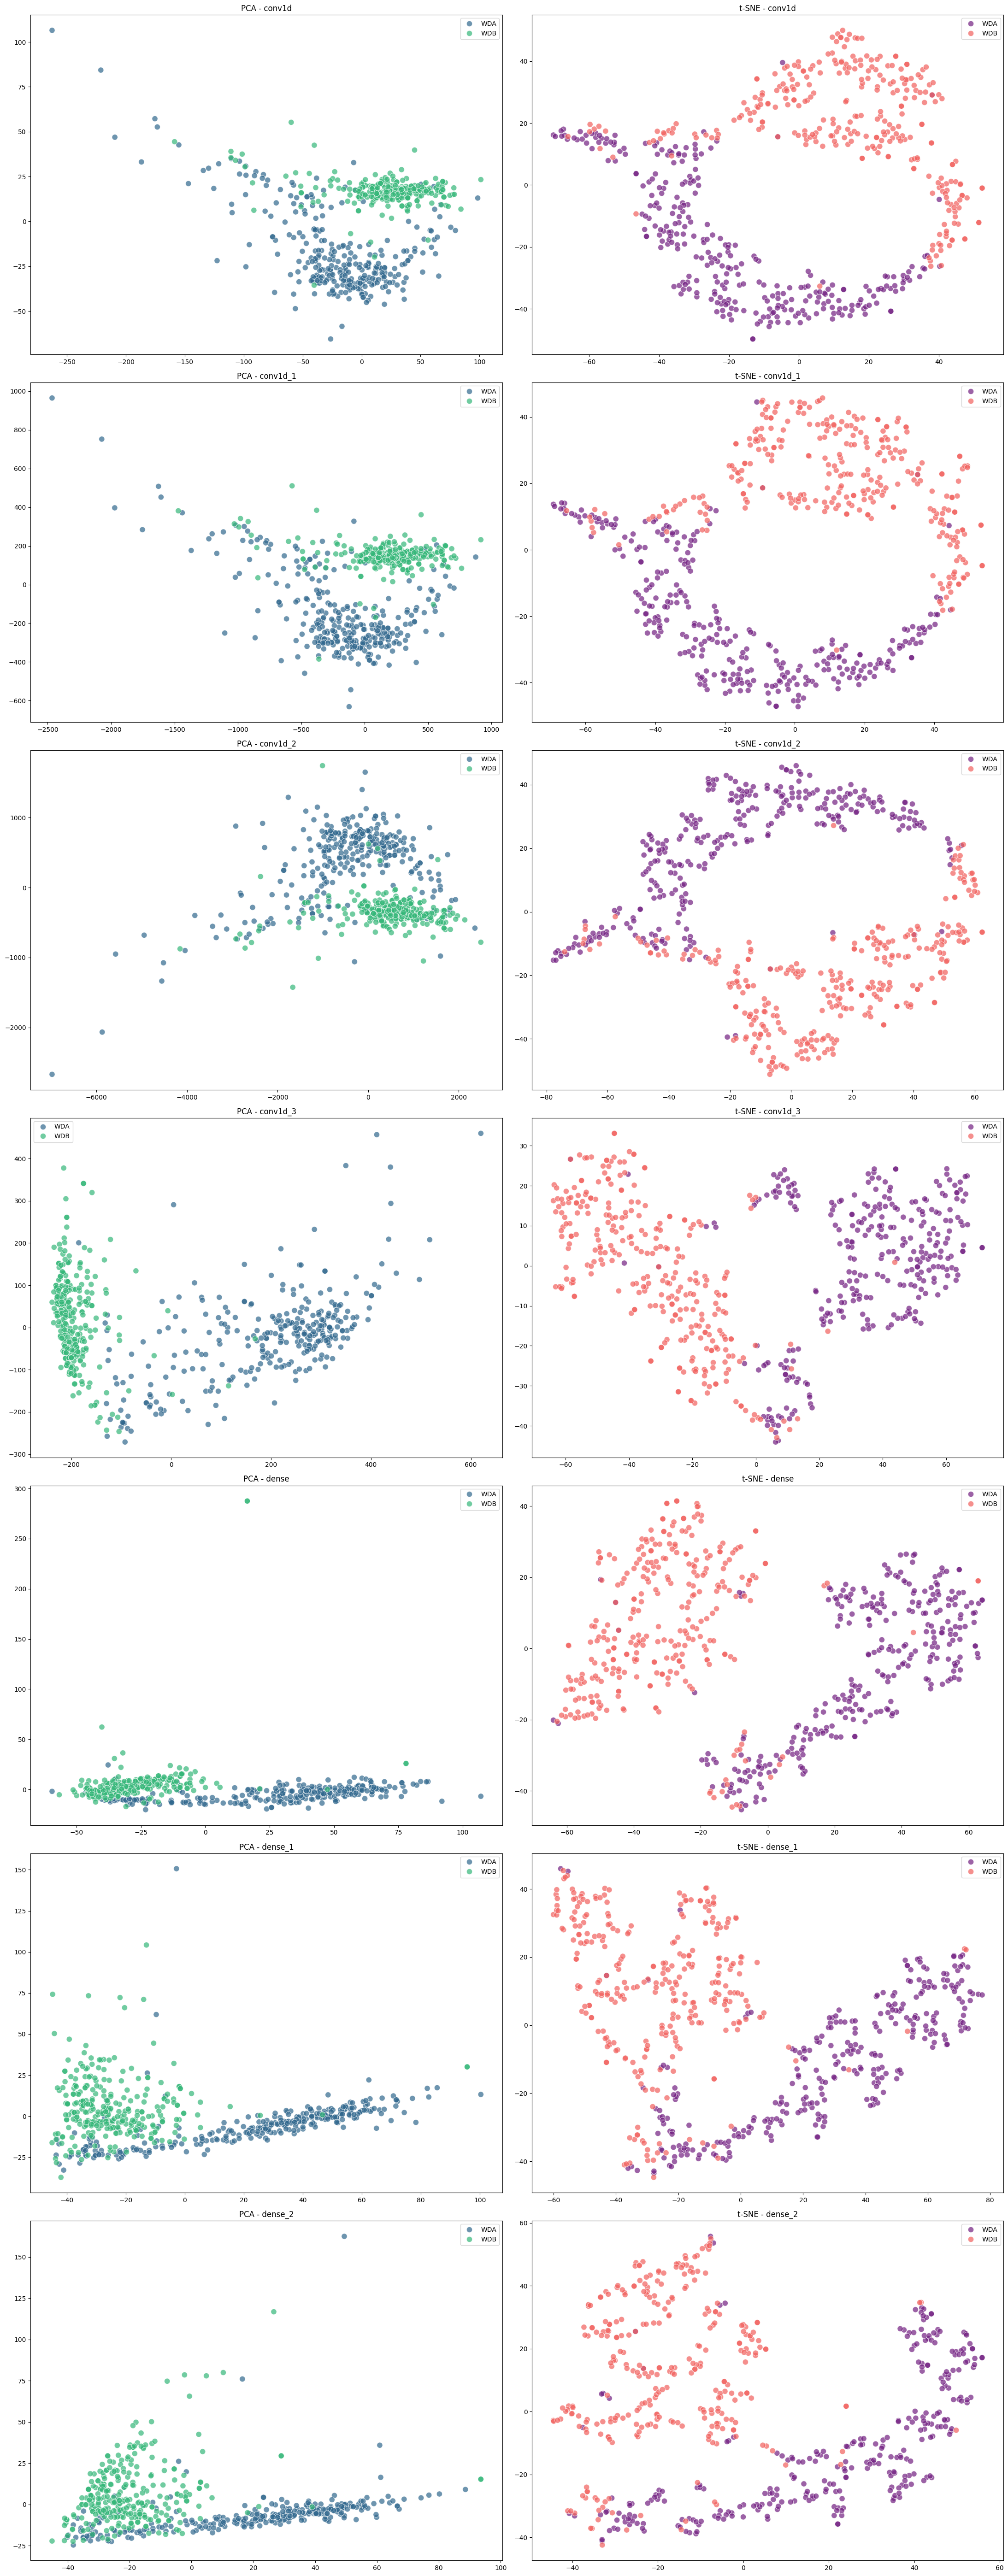

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import gc
import os

capas_interes = [l.name for l in full_model.layers if 'conv1d' in l.name or 'dense' in l.name]
capas_interes = capas_interes[:-1] # Excluir salida final

n_capas = len(capas_interes)
#fig, axes = plt.subplots(n_capas, 2, figsize=(18, 6 * n_capas))
fig, axes = plt.subplots(n_capas, 2, figsize=(22, 8 * n_capas))
for i, nombre_capa in enumerate(capas_interes):
    input_layer = tf.keras.layers.Input(shape=(3750, 1))
    x = input_layer
    for layer in full_model.layers:
        x = layer(x)
        if layer.name == nombre_capa:
            break
    
    extractor_temporal = Model(inputs=input_layer, outputs=x)
    features = extractor_temporal.predict(X_input, verbose=0)
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)
    features = np.nan_to_num(features)

    # reducción intermedia (PCA 50) para evitar MemoryError en t-SNE
    feat_pre = PCA(n_components=min(50, features.shape[1])).fit_transform(features)
    
    pca_2d = PCA(n_components=2).fit_transform(feat_pre)
    tsne_2d = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(feat_pre)
    
    # Graficar PCA
    sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=y_labels, ax=axes[i,0], palette='viridis', s=80, alpha=0.7)
    axes[i,0].set_title(f'PCA - {nombre_capa}')
    
    # Graficar t-SNE
    sns.scatterplot(x=tsne_2d[:,0], y=tsne_2d[:,1], hue=y_labels, ax=axes[i,1], palette='magma', s=80, alpha=0.7, edgecolor='w')
    axes[i,1].set_title(f't-SNE - {nombre_capa}')
    
    # Liberar memoria RAM
    del extractor_temporal, features, feat_pre
    gc.collect()

plt.tight_layout()
plt.show()

--- RESUMEN DEL EXTRACTOR FINAL (CAPA DE SALIDA) ---


Model: "functional_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_input (InputLayer)            │ (None, 3750, 1)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 1874, 128)           │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 937, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 467, 64)             │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 233, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 115, 32)             │           8,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 57, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 27, 16)              │           2,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 13, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 208)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          26,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │             396 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81,244 (317.36 KB)

 Trainable params: 81,244 (317.36 KB)

 Non-trainable params: 0 (0.00 B)

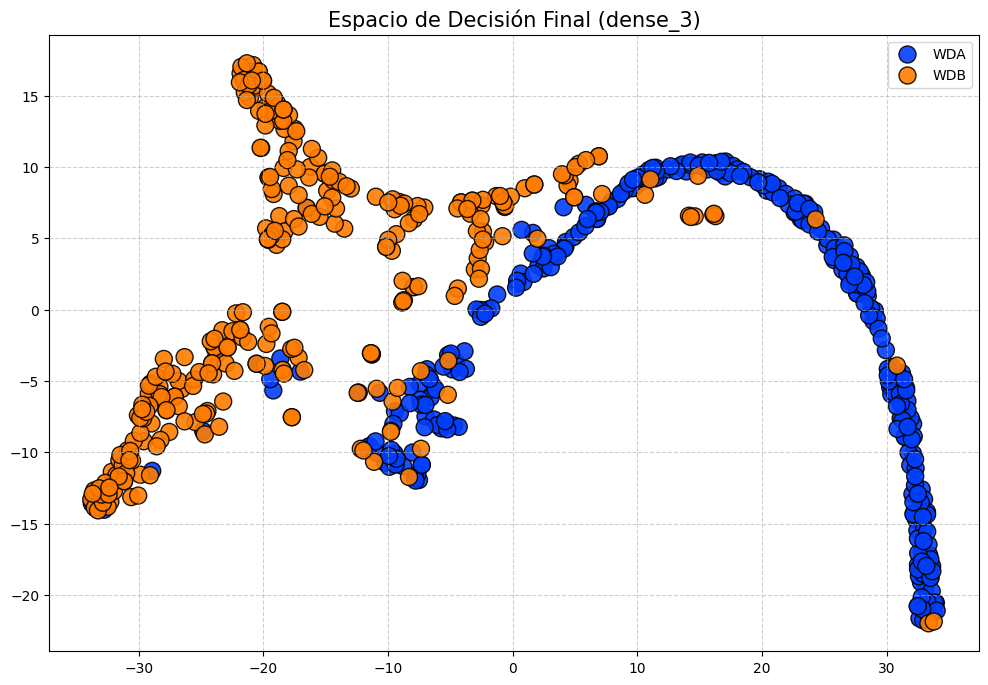

In [42]:
# --- CELDA DE VALIDACIÓN FINAL: CAPA DE SALIDA (DENSE_3) ---

# 1. "DESPERTAR" EL MODELO (Fix para el AttributeError)
# Pasamos un dato falso con la forma (1, 3750, 1) para inicializar los nodos de entrada
dummy_input = np.zeros((1, 3750, 1))
full_model(dummy_input) # Esto "llama" al modelo y define los inputs/outputs

# 2. Definimos el extractor para la última capa
ultima_capa = 'dense_3' 

# Intentamos obtener la capa. Si falla, es que el nombre es distinto.
try:
    extractor_final = Model(inputs=full_model.inputs, outputs=full_model.get_layer(ultima_capa).output)
    
    print("--- RESUMEN DEL EXTRACTOR FINAL (CAPA DE SALIDA) ---")
    extractor_final.summary()

    # 3. Extraemos las predicciones
    final_features = extractor_final.predict(X_input, verbose=0)
    final_features = np.nan_to_num(final_features)

    # 4. Reducción para visualización (Perplejidad 32)
    tsne_final = TSNE(n_components=2, perplexity=32, random_state=42, init='pca').fit_transform(final_features)

    # 5. Gráfico
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=tsne_final[:,0], y=tsne_final[:,1], hue=y_labels, 
                    palette='bright', s=150, alpha=0.9, edgecolor='black')

    plt.title(f'Espacio de Decisión Final ({ultima_capa})', fontsize=15)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

except ValueError:
    print(f"Error: No se encontró la capa '{ultima_capa}'. Revisa el model.summary() para ver el nombre exacto.")

--------------------------------------------------

Extrayendo características del espacio latente...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Calculando PCA...
Calculando t-SNE (esto puede tardar un poco)...


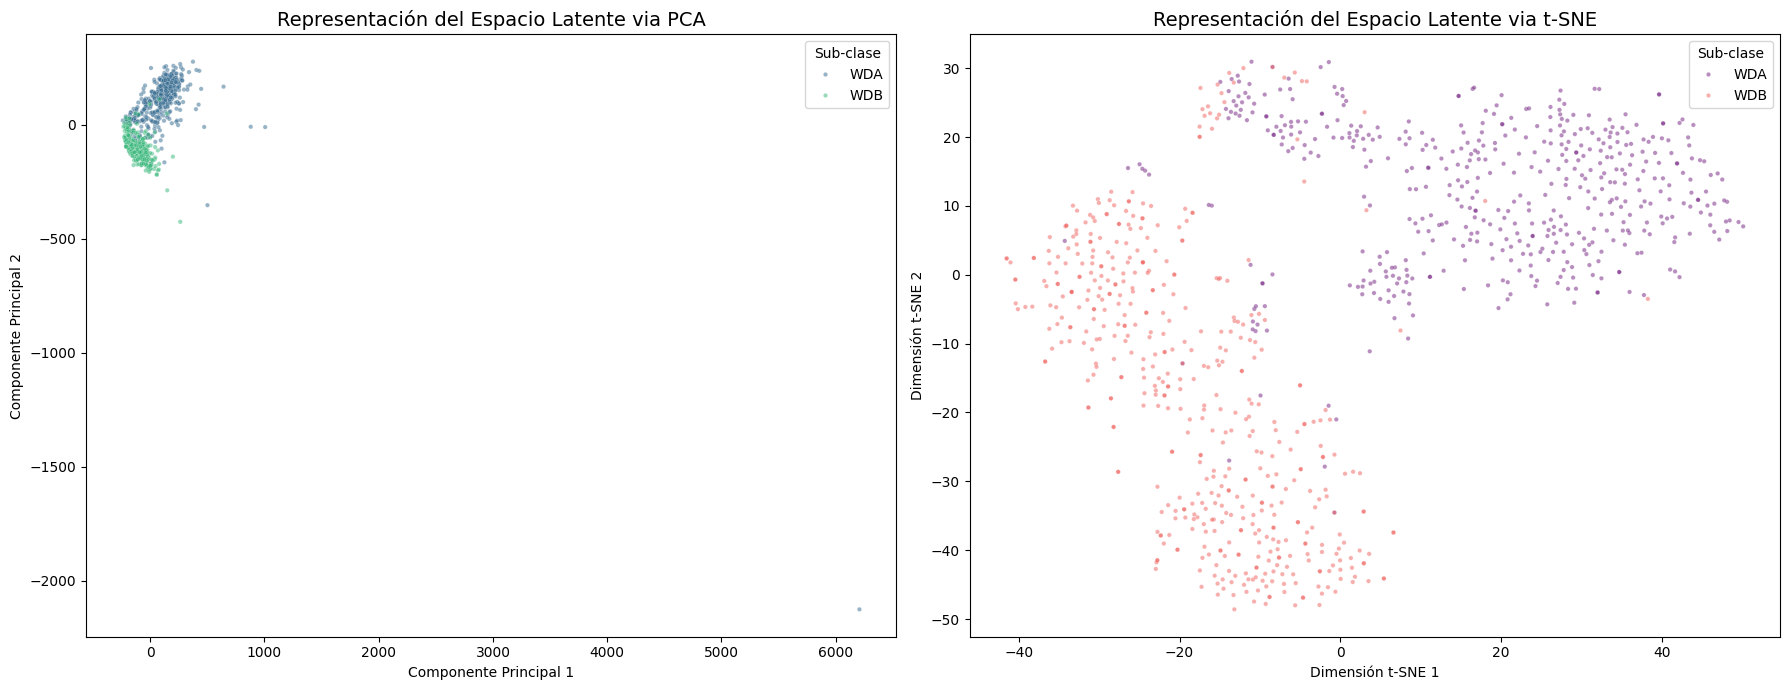

In [46]:
# 1. Extraer las características del espacio latente (las 32 neuronas)
print("Extrayendo características del espacio latente...")
latent_features = latent_extractor.predict(X_input, batch_size=64)

# 2. Aplicar PCA (Reducción lineal para ver la varianza principal)
print("Calculando PCA...")
pca = PCA(n_components=2)
pca_results = pca.fit_transform(latent_features)

# 3. Aplicar t-SNE (Reducción no lineal para encontrar cúmulos/clusters)
# Nota: Con 14,907 datos, t-SNE puede tardar un par de minutos.
print("Calculando t-SNE (esto puede tardar un poco)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
tsne_results = tsne.fit_transform(latent_features)

# 4. Crear los gráficos
plt.figure(figsize=(18, 7))

# Gráfico PCA
plt.subplot(1, 2, 1)
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=y_labels, 
                palette='viridis', alpha=0.5, s=10)
plt.title('Representación del Espacio Latente via PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Sub-clase')

# Gráfico t-SNE
plt.subplot(1, 2, 2)
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=y_labels, 
                palette='magma', alpha=0.5, s=10)
plt.title('Representación del Espacio Latente via t-SNE', fontsize=14)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Sub-clase')

plt.tight_layout()
plt.show()

In [ ]:
---

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

project_dir = Path().resolve().parent

train_set = pd.read_csv(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\train_set.csv'))
valid_set = pd.read_csv(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\valid_set.csv'))

train_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\alt_train_spectrum_matrix.npy'))
valid_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\alt_valid_spectrum_matrix.npy'))

print(train_set.shape, train_spectrum_matrix.shape)
print(valid_set.shape, valid_spectrum_matrix.shape)

(3366, 2) (10912, 4200)
(1123, 2) (3639, 4200)


In [2]:
print("TRAIN")
print(train_set['classID'].value_counts())

print("\nVALID")
print(valid_set['classID'].value_counts())

TRAIN
classID
WDA      2169
WD+MS     327
WDC       215
WDB       201
WDELM     135
WD         80
sdX        70
CV         67
WDZ        55
WDH        31
WDO        10
WDQ         6
Name: count, dtype: int64

VALID
classID
WDA      723
WD+MS    109
WDC       72
WDB       68
WDELM     45
WD        27
sdX       23
CV        22
WDZ       19
WDH       10
WDO        3
WDQ        2
Name: count, dtype: int64


In [3]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

project_dir = Path().resolve().parent

train_set = pd.read_csv(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\train_set.csv'))
valid_set = pd.read_csv(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\valid_set.csv'))

train_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\training_spectrum_matrix.npy'))
valid_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\validation_spectrum_matrix.npy'))

print(train_set.shape, train_spectrum_matrix.shape)
print(valid_set.shape, valid_spectrum_matrix.shape)

(3366, 2) (3366, 4200)
(1123, 2) (1123, 4200)


In [4]:
import pandas as pd
import numpy as np

# Unir CSV y matrices
all_set = pd.concat([train_set, valid_set], ignore_index=True)
all_spectra = np.vstack([train_spectrum_matrix, valid_spectrum_matrix])

print(all_set.shape, all_spectra.shape)

# Verificación rápida
assert len(all_set) == len(all_spectra)

# Elegimos clases
classes_to_use = ['WDA', 'WDB']
mask = all_set['classID'].isin(classes_to_use)

subset_set = all_set.loc[mask].copy()
subset_spectra = all_spectra[mask.values]

print(subset_set['classID'].value_counts())
print(subset_spectra.shape)

(4489, 2) (4489, 4200)
classID
WDA    2892
WDB     269
Name: count, dtype: int64
(3161, 4200)


In [5]:
# Mezclar índices por clase y tomar la misma cantidad
rng = np.random.default_rng(42)

idx_wda = subset_set.index[subset_set['classID'] == 'WDA'].to_numpy()
idx_wdb = subset_set.index[subset_set['classID'] == 'WDB'].to_numpy()

n_per_class = min(len(idx_wda), len(idx_wdb), 150)  # cambia 150 si quieres más o menos

sel_wda = rng.choice(idx_wda, size=n_per_class, replace=False)
sel_wdb = rng.choice(idx_wdb, size=n_per_class, replace=False)

selected_idx = np.concatenate([sel_wda, sel_wdb])
rng.shuffle(selected_idx)

reduced_set = all_set.loc[selected_idx].copy().reset_index(drop=True)
reduced_spectra = all_spectra[selected_idx]

print(reduced_set['classID'].value_counts())
print(reduced_spectra.shape)

classID
WDA    150
WDB    150
Name: count, dtype: int64
(300, 4200)


In [6]:
X = reduced_spectra[..., np.newaxis]   # pasa de (N, 4200) a (N, 4200, 1)
y = reduced_set['classID'].to_numpy()

print(X.shape)
print(pd.Series(y).value_counts())

(300, 4200, 1)
WDA    150
WDB    150
Name: count, dtype: int64


In [10]:
from pathlib import Path
import sys
import inspect

project_dir = Path().resolve().parent
sys.path.append(str(project_dir))

import src.features.build_features as bfs

print(inspect.getsource(bfs.data_processing_and_loading))

def data_processing_and_loading(sdss_data_path, block_df, first_bin=48, last_bin=-400, normalize='mean'):
    """
    The following function takes a dataframe consisting of two columns: filename of .dat
    file and class ID, and returns a numpy array consisting of the spectrum data matrix, 
    processing the dataframe from top to bottom, so the numpy array elements are added in this order.

    This functions also does some flux data pre-processing, trimming the edges of the signal 
    and normalizing flux magnitud to 1 around 5847 [Angstrom].

    The dat files are assumed to share a common wavelenght vector. 

    Parameters
    ----------
    :sdss_data_path: path to folders where each subfolder contains .dat files.
    :block_df: dataframe with two columns, filenames and class id.
    :stars_enconding: dictionary with one hot encoding. 
    :first_bin: start of array to consider, must be positive.
    :last_bin: Last bin from array to consider, must be negative.

    Returns
   

In [ ]:
from pathlib import Path
import sys

project_dir = Path().resolve().parent
sys.path.append(str(project_dir))

In [9]:
import sys
sys.path.append(str(Path(__file__).resolve().parent.parent))

NameError: name '__file__' is not defined

In [8]:
import inspect
import src.features.build_features as bfs

print(inspect.getsource(bfs.data_processing_and_loading))

ModuleNotFoundError: No module named 'src'

In [7]:
from tensorflow import keras
import os
import numpy as np

model_path = os.path.join(project_dir, r"models\model_4C_3FC.h5")
model = keras.models.load_model(model_path)

model.build((None, 4200, 1))
_ = model(np.zeros((1, 4200, 1), dtype=np.float32), training=False)

latent_model = keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("dense_2").output
)

Z = latent_model.predict(X)
print(Z.shape)

C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


ValueError: Sequential model 'sequential' has already been configured to use input shape (None, 3750, 1). You cannot build it with input_shape (None, 4200, 1)